<a href="https://colab.research.google.com/github/samanpython098/Replication_Project_LOG6307E/blob/main/mining_pipeline_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [ ]:
!pip install huggingface_hub pandas requests scipy matplotlib

In [1]:
!pip install -q huggingface_hub pandas requests scipy matplotlib

In [2]:
import json
import re
import time
from datetime import datetime, timezone
from getpass import getpass
from pathlib import Path

import matplotlib
matplotlib.use("Agg")  # figures are saved to disk and displayed explicitly below
import matplotlib.pyplot as plt
import pandas as pd
import requests
from huggingface_hub import snapshot_download
from scipy.stats import chi2_contingency, mannwhitneyu

DATA_DIR = Path("/content/data")
FIG_DIR = Path("/content/figures")
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "data.jsonl"
CLEAN_PATH = DATA_DIR / "clean_data.json"
METRICS_PATH = DATA_DIR / "pr_metrics.csv"

### GitHub token

Paste a **fresh** personal access token when prompted (never hardcode one in
a notebook cell — cell output and notebook JSON get saved/shared). If you
already revoked/rotated an old token, this is where the new one goes.

In [3]:
GITHUB_TOKEN = getpass("Enter your GitHub token: ")
if not GITHUB_TOKEN:
    raise ValueError("No GitHub token entered.")
print("Token loaded:", bool(GITHUB_TOKEN), "| length:", len(GITHUB_TOKEN))

Enter your GitHub token: ··········
Token loaded: True | length: 93


## Part 1 — Repository Mining

Downloads the AIDev PR metadata (AI vs. human pull requests), samples a
subset, then mines full PR detail (comments, reviews, inline review
comments) from the GitHub GraphQL API.

In [4]:
BATCH_SIZE = 15
SAMPLE_FRAC_AI = 0.5  # keep the human set intact, subsample the (larger) AI set
RANDOM_STATE = 42

PR_QUERY_TEMPLATE = """
p{i}: repository(owner:"{owner}", name:"{name}") {{
  pullRequest(number:{number}) {{
    number state createdAt closedAt mergedAt
    author {{ login __typename }}

    comments(first:100) {{
      totalCount
      nodes {{
        author {{ login __typename }}
        createdAt
        body
      }}
    }}

    reviews(first:50) {{
      totalCount
      nodes {{
        author {{ login __typename }}
        state
        submittedAt
        body

        comments(first:50) {{
          totalCount
          nodes {{
            author {{ login __typename }}
            createdAt
            body
          }}
        }}
      }}
    }}
  }}
}}
"""

#### `ensure_dataset_downloaded()`

In [5]:
def ensure_dataset_downloaded():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    required_files = {"pull_request.parquet", "human_pull_request.parquet"}
    existing_files = {p.name for p in DATA_DIR.glob("*.parquet")}

    if required_files.issubset(existing_files):
        return

    snapshot_download(
        "hao-li/AIDev",
        repo_type="dataset",
        revision="v3",
        local_dir=DATA_DIR,
        allow_patterns=list(required_files),
    )

    # snapshot_download can place files in subfolders; flatten them into DATA_DIR
    for path in DATA_DIR.rglob("*.parquet"):
        if path.name in required_files and path.parent != DATA_DIR:
            target = DATA_DIR / path.name
            if not target.exists():
                path.rename(target)

#### `build_frame()`

In [6]:
def build_frame() -> pd.DataFrame:
    ai_pr = pd.read_parquet(DATA_DIR / "pull_request.parquet")
    hu_pr = pd.read_parquet(DATA_DIR / "human_pull_request.parquet")

    columns = ["id", "number", "title", "created_at", "repo_url", "html_url", "agent", "group"]
    ai_pr = ai_pr.copy()
    hu_pr = hu_pr.copy()
    ai_pr["group"] = "ai"
    hu_pr["group"] = "human"

    frame = pd.concat([ai_pr[columns], hu_pr[columns]], ignore_index=True)
    frame = frame.drop_duplicates(subset="id")

    frame = pd.concat(
        [
            frame[frame["group"] == "ai"].sample(frac=SAMPLE_FRAC_AI, random_state=RANDOM_STATE),
            frame[frame["group"] == "human"],
        ],
        ignore_index=True,
    )

    repositories = frame["html_url"].str.extract(r"github\.com/([^/]+)/([^/]+)/pull/\d+")
    frame["owner"] = repositories[0]
    frame["name"] = repositories[1]
    frame = frame.dropna(subset=["owner", "name"])

    return frame

#### `_fetch_rate_limit_reset()`

In [7]:
def _fetch_rate_limit_reset() -> "datetime | None":
    rate_query = "query { rateLimit { limit remaining resetAt } }"
    try:
        resp = requests.post(
            "https://api.github.com/graphql",
            json={"query": rate_query},
            headers={"Authorization": f"bearer {GITHUB_TOKEN}"},
            timeout=30,
        )
        rate_data = resp.json().get("data", {}).get("rateLimit", {})
        reset_at = rate_data.get("resetAt")
        if reset_at:
            return datetime.fromisoformat(reset_at.replace("Z", "+00:00"))
    except Exception:
        pass
    return None

#### `mine()`

In [8]:
def mine(frame: pd.DataFrame):
    rows = list(frame.itertuples(index=False))
    total = len(rows)
    total_batches = (total + BATCH_SIZE - 1) // BATCH_SIZE

    print(f"Total PRs: {total}")
    print(f"Total batches: {total_batches}")

    with DATA_PATH.open("w", encoding="utf-8") as f:
        for start in range(0, total, BATCH_SIZE):
            chunk = rows[start:start + BATCH_SIZE]
            batch_number = start // BATCH_SIZE + 1
            print(f"\nBatch {batch_number}/{total_batches} ({start + 1}-{min(start + BATCH_SIZE, total)} / {total})")

            parts = [
                PR_QUERY_TEMPLATE.format(i=i, owner=r.owner, name=r.name, number=int(r.number))
                for i, r in enumerate(chunk)
            ]
            query = "query {\n" + "\n".join(parts) + "\n}"

            while True:
                try:
                    response = requests.post(
                        "https://api.github.com/graphql",
                        json={"query": query},
                        headers={"Authorization": f"bearer {GITHUB_TOKEN}"},
                        timeout=60,
                    )
                    print(f"HTTP status: {response.status_code}")

                    if response.status_code != 200:
                        print("GitHub error:", response.text[:1000])
                        reset_timestamp = response.headers.get("X-RateLimit-Reset")
                        if reset_timestamp:
                            reset_time = datetime.fromtimestamp(int(reset_timestamp), tz=timezone.utc)
                            wait_seconds = max(0, (reset_time - datetime.now(timezone.utc)).total_seconds()) + 5
                            print(f"Waiting until {reset_time.astimezone().strftime('%H:%M:%S')}...")
                            time.sleep(wait_seconds)
                            continue
                        print("No reset time available. Waiting 60 seconds...")
                        time.sleep(60)
                        continue

                    result = response.json()
                    errors = result.get("errors", [])
                    rate_limited = any(
                        error.get("type") == "RATE_LIMIT" or error.get("code") == "graphql_rate_limit"
                        for error in errors
                    )

                    if rate_limited:
                        print("GitHub GraphQL rate limit reached.")
                        reset_time = _fetch_rate_limit_reset()
                        if reset_time:
                            wait_seconds = max(0, (reset_time - datetime.now(timezone.utc)).total_seconds()) + 5
                            print(f"Reset at: {reset_time.astimezone().strftime('%Y-%m-%d %H:%M:%S')}")
                            print(f"Waiting {wait_seconds / 60:.1f} minutes...")
                            time.sleep(wait_seconds)
                        else:
                            print("Could not determine reset time. Waiting 60 seconds...")
                            time.sleep(60)
                        print("Retrying the same batch...")
                        continue

                    if errors:
                        print("GraphQL errors:", json.dumps(errors, indent=2)[:3000])

                    found = 0
                    for i, r in enumerate(chunk):
                        key = f"p{i}"
                        pull_request = (result.get("data", {}).get(key, {}) or {}).get("pullRequest")
                        if pull_request is not None:
                            found += 1
                        f.write(json.dumps({
                            "pr_id": int(r.id),
                            "group": r.group,
                            "agent": r.agent,
                            "repo": f"{r.owner}/{r.name}",
                            "number": int(r.number),
                            "found": pull_request is not None,
                            "pr": pull_request,
                        }) + "\n")
                    f.flush()
                    print(f"Found: {found}/{len(chunk)}")
                    break  # batch succeeded

                except Exception as e:
                    print(f"ERROR in batch {batch_number}: {type(e).__name__}: {e}")
                    print("Waiting 30 seconds before retrying...")
                    time.sleep(30)

            time.sleep(1)  # be polite between successful batches

    print("\nMining finished.")

#### Run Part 1

In [ ]:
ensure_dataset_downloaded()
if not DATA_PATH.exists():
    pr_frame = build_frame()
    mine(pr_frame)
else:
    print(f"{DATA_PATH} already exists, skipping mining.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Total PRs: 23416
Total batches: 1562

Batch 1/1562 (1-15 / 23416)
HTTP status: 200
GraphQL errors: [
  {
    "type": "NOT_FOUND",
    "path": [
      "p10"
    ],
    "locations": [
      {
        "line": 363,
        "column": 1
      }
    ],
    "message": "Could not resolve to a Repository with the name 'antiwork/flexile'."
  }
]
Found: 14/15

Batch 2/1562 (16-30 / 23416)
HTTP status: 200
Found: 15/15

Batch 3/1562 (31-45 / 23416)
HTTP status: 200
GraphQL errors: [
  {
    "type": "NOT_FOUND",
    "path": [
      "p10"
    ],
    "locations": [
      {
        "line": 363,
        "column": 1
      }
    ],
    "message": "Could not resolve to a Repository with the name 'antiwork/helper'."
  }
]
Found: 14/15

Batch 4/1562 (46-60 / 23416)
HTTP status: 200
Found: 15/15

Batch 5/1562 (61-75 / 23416)
HTTP status: 200
Found: 15/15

Batch 6/1562 (76-90 / 23416)
HTTP status: 200
GraphQL errors: [
  {
    "type": "NOT_FOUND",
    "path": [
      "p3"
    ],
    "locations": [
      {
    

## Part 2 — Data Cleaning and Classification

Drops PRs that failed to fetch, removes bot noise (while keeping AI-agent
PRs that happen to post from bot-flagged accounts), strips markdown from
comment bodies, and flags clarification/approval/rejection language.

#### Bot detection

In [1]:
import re

BOT_SUFFIX_RE = re.compile(r"\[bot\]$", re.IGNORECASE)

COMMON_BOTS_RE = re.compile(
    r"(?i)^(dependabot|renovate|semantic-release|azure-sdk|calcom-bot|"
    r"github-actions|allcontributors|imgbot|snyk-bot|codecov|netlify|vercel|"
    r"robobun|claassistant|codecov-commenter|vdaas-ci|autogpt-agent|coveralls|"
    r".+-ci|.+-commenter|.+-service\d*|.+-engineering-service\d*|.+-bot\d*)$"
)

In [2]:
def is_bot(login, typename) -> bool:
    if not isinstance(login, str) or not login:
        return True
    if str(typename).lower() == "bot":
        return True
    stripped = BOT_SUFFIX_RE.sub("", login).strip().lower()
    return bool(BOT_SUFFIX_RE.search(login)) or bool(COMMON_BOTS_RE.match(stripped))

#### Text cleaning

In [3]:
FENCE_RE = re.compile(r"```.*?```", re.S)
INLINE_CODE_RE = re.compile(r"`[^`\n]+`")
HTML_COMMENT_RE = re.compile(r"<!--.*?-->", re.S)
HTML_TAG_RE = re.compile(r"<[^>]+>")
QUOTE_LINE_RE = re.compile(r"^\s*>.*$", re.M)
URL_RE = re.compile(r"https?://\S+")
IMG_RE = re.compile(r"!\[[^\]]*\]\([^)]*\)")

In [4]:
def strip_markdown(body: str) -> str:
    if not body:
        return ""
    text = HTML_COMMENT_RE.sub(" ", body)
    text = FENCE_RE.sub(" ", text)
    text = IMG_RE.sub(" ", text)
    text = INLINE_CODE_RE.sub(" ", text)
    text = QUOTE_LINE_RE.sub(" ", text)
    text = HTML_TAG_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()

In [5]:
def add_text_fields(event: dict) -> None:
    event["text"] = strip_markdown(event.get("body", ""))
    event["n_words"] = len(event["text"].split())

#### Language lexicons

In [6]:
CLARIFY_RE = re.compile("|".join([
    r"\b(?:could|can|would)\s+you\s+(?:please\s+)?(?:explain|clarify|elaborate|confirm)",
    r"\bwhy\s+(?:is|are|was|were|does|did|do|not)\b",
    r"\bwhat\s+(?:is|are|was|does|do|did)\s+the\b",
    r"\bclarif(?:y|ication)\b",
    r"\bnot\s+sure\s+(?:what|why|how|if|that)\b",
    r"\bcan\s+you\s+explain\b",
    r"\bwhat'?s\s+the\s+(?:reason|purpose|point|rationale)\b",
    r"\bany\s+reason\s+(?:why|for)\b",
    r"\bdo\s+we\s+(?:need|want)\b",
    r"\bis\s+(?:this|that|it)\s+(?:intentional|intended|necessary|correct)\b",
]), re.I)

APPROVE_RE = re.compile("|".join([
    r"\blgtm\b", r"\bsgtm\b", r"\blooks?\s+good\b", r"\bship\s+it\b",
    r"\bapprov(?:e|ed|ing)\b", r"\bnice\s+(?:work|job|catch)\b",
    r"\bgreat\s+(?:work|job|catch)\b", r"\bmerging\b", r"\bwill\s+merge\b",
    r"\bthanks?\s+for\s+(?:the\s+)?(?:fix|patch|pr|work)\b", r"\bperfect\b",
]), re.I)

REJECT_RE = re.compile("|".join([
    r"\bplease\s+(?:fix|revert|address|update|remove|change)\b", r"\bblocking\b",
    r"\bdo(?:\s+not|n'?t)\s+merge\b", r"\bneeds?\s+(?:work|changes|fixing)\b",
    r"\brevert(?:ing)?\s+this\b", r"\bclosing\s+(?:this|in\s+favou?r)\b",
    r"\bthis\s+is\s+wrong\b", r"\bwon'?t\s+(?:work|merge)\b", r"\bincorrect\b",
    r"\bbreaks?\s+(?:the\s+)?(?:build|tests?)\b", r"\bregression\b",
    r"\bplease\s+don'?t\b", r"\bnot\s+(?:correct|right)\b",
]), re.I)

In [7]:
def add_language_flags(event: dict) -> None:
    text = event.get("text", "")
    event["is_clarification"] = bool(CLARIFY_RE.search(text))
    event["has_approval_lang"] = bool(APPROVE_RE.search(text))
    event["has_rejection_lang"] = bool(REJECT_RE.search(text))

#### Pipeline

In [8]:
def load_raw():
    with DATA_PATH.open("r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

In [9]:
def remove_bots(data):
    # IMPORTANT: many AI coding agents (e.g. GitHub Copilot workspace,
    # Devin, OpenHands) open pull requests from accounts that GitHub flags
    # as bots (login ends in "[bot]", __typename == "Bot"). If we dropped
    # every bot-authored PR outright we would delete most of the "ai" group,
    # defeating the study. So: only treat a bot-authored PR as noise to
    # discard when it is NOT already labeled "ai" by the dataset. Bot
    # *comments/reviews* (CI bots, dependabot, etc.) are still stripped out
    # for every PR regardless of group, since those are noise either way.
    bot_pr_ids = set()
    for r in data:
        pr = r.get("pr")
        if not pr:
            continue
        if r.get("group") == "ai":
            continue
        author = pr.get("author") or {}
        if is_bot(author.get("login"), author.get("__typename")):
            bot_pr_ids.add(r["pr_id"])

    clean_data = []
    for r in data:
        if r["pr_id"] in bot_pr_ids:
            continue
        pr = r.get("pr")
        if not pr:
            continue

        comments = pr.get("comments", {}).get("nodes", [])
        pr["comments"]["nodes"] = [
            c for c in comments
            if not is_bot((c.get("author") or {}).get("login"), (c.get("author") or {}).get("__typename"))
        ]

        clean_reviews = []
        for review in pr.get("reviews", {}).get("nodes", []):
            author = review.get("author") or {}
            if is_bot(author.get("login"), author.get("__typename")):
                continue
            review_comments = review.get("comments", {}).get("nodes", [])
            review["comments"]["nodes"] = [
                c for c in review_comments
                if not is_bot((c.get("author") or {}).get("login"), (c.get("author") or {}).get("__typename"))
            ]
            clean_reviews.append(review)
        pr["reviews"]["nodes"] = clean_reviews

        clean_data.append(r)

    print(f"Bot PRs removed: {len(bot_pr_ids)}")
    return clean_data

In [10]:
def annotate_text_and_language(data):
    for r in data:
        pr = r.get("pr")
        if not pr:
            continue
        for comment in pr.get("comments", {}).get("nodes", []):
            add_text_fields(comment)
            add_language_flags(comment)
        for review in pr.get("reviews", {}).get("nodes", []):
            add_text_fields(review)
            add_language_flags(review)
            for comment in review.get("comments", {}).get("nodes", []):
                add_text_fields(comment)
                add_language_flags(comment)
    return data

#### Run Part 2

In [13]:
from pathlib import Path
import json
import pandas as pd

DATA_PATH = Path.cwd() / "data" / "data.jsonl"

print("Looking for:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

Looking for: /content/data/data.jsonl
Exists: False


In [14]:
from pathlib import Path

print("Current directory:", Path.cwd())

for path in Path.cwd().rglob("*"):
    if path.is_file():
        print(path)

Current directory: /content
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/active_config
/content/.config/config_sentinel
/content/.config/.last_update_check.json
/content/.config/.last_opt_in_prompt.yaml
/content/.config/default_configs.db
/content/.config/.last_survey_prompt.yaml
/content/.config/gce
/content/sample_data/anscombe.json
/content/sample_data/README.md
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/.config/configurations/config_default
/content/.config/logs/2026.09.16/13.26.17.091876.log
/content/.config/logs/2026.09.16/13.25.37.877256.log
/content/.config/logs/2026.09.16/13.26.04.283691.log
/content/.config/logs/2026.09.16/13.26.29.139725.log
/content/.config/logs/2026.09.16/13.26.30.459687.log
/content/.config/logs/2026.09.16/13.26.15.129583.log


In [15]:
from pathlib import Path
from huggingface_hub import snapshot_download

data_dir = Path("/content/data")
data_dir.mkdir(parents=True, exist_ok=True)

snapshot_download(
    "hao-li/AIDev",
    repo_type="dataset",
    revision="v3",
    local_dir=data_dir,
    allow_patterns=[
        "pull_request.parquet",
        "human_pull_request.parquet"
    ]
)

print("Files downloaded:")
for p in data_dir.rglob("*.parquet"):
    print(p)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Files downloaded:
/content/data/pull_request.parquet
/content/data/human_pull_request.parquet


In [16]:
import pandas as pd

ai_pr = pd.read_parquet("/content/data/pull_request.parquet")
hu_pr = pd.read_parquet("/content/data/human_pull_request.parquet")

print("AI PRs:", len(ai_pr))
print("Human PRs:", len(hu_pr))

print("\nAI columns:")
print(ai_pr.columns.tolist())

print("\nHuman columns:")
print(hu_pr.columns.tolist())

AI PRs: 33596
Human PRs: 6618

AI columns:
['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url']

Human columns:
['id', 'number', 'title', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_url', 'html_url', 'body', 'agent']


In [17]:
import pandas as pd

# Add group labels
ai_pr["group"] = "ai"
hu_pr["group"] = "human"

# Create a balanced sample
N = 500

ai_sample = ai_pr.sample(n=N, random_state=42)
human_sample = hu_pr.sample(n=N, random_state=42)

frame = pd.concat(
    [
        ai_sample,
        human_sample
    ],
    ignore_index=True
)

# Extract repository owner/name
repositories = frame["html_url"].str.extract(
    r"github\.com/([^/]+)/([^/]+)/pull/\d+"
)

frame["owner"] = repositories[0]
frame["name"] = repositories[1]

frame = frame.dropna(subset=["owner", "name"])

print("Total PRs selected:", len(frame))
print("\nGroups:")
print(frame["group"].value_counts())

print("\nRepositories:", frame["owner"].nunique())

Total PRs selected: 1000

Groups:
group
ai       500
human    500
Name: count, dtype: int64

Repositories: 321


In [18]:
test_frame = frame.head(10)

print(test_frame[
    ["group", "owner", "name", "number", "html_url"]
].to_string(index=False))

group          owner                        name  number                                                              html_url
   ai        liam-hq                        liam    2044                             https://github.com/liam-hq/liam/pull/2044
   ai KomodoPlatform               komodo-wallet    3005             https://github.com/KomodoPlatform/komodo-wallet/pull/3005
   ai      mochilang                       mochi   10166                         https://github.com/mochilang/mochi/pull/10166
   ai     MontrealAI          AGI-Alpha-Agent-v0    2221            https://github.com/MontrealAI/AGI-Alpha-Agent-v0/pull/2221
   ai  AzureCosmosDB data-migration-desktop-tool     187 https://github.com/AzureCosmosDB/data-migration-desktop-tool/pull/187
   ai      theopenco                  llmgateway     240                      https://github.com/theopenco/llmgateway/pull/240
   ai    jaseci-labs                      jaseci    1978                       https://github.com/jaseci-labs/j

In [34]:
from getpass import getpass

GITHUB_TOKEN = getpass("Paste your NEW GitHub token: ")

if not GITHUB_TOKEN:
    raise ValueError("No token entered.")

import requests

response = requests.get(
    "https://api.github.com/user",
    headers={
        "Authorization": f"Bearer {GITHUB_TOKEN}",
        "Accept": "application/vnd.github+json"
    }
)

print("HTTP status:", response.status_code)
print(response.json())

Paste your NEW GitHub token: ··········
HTTP status: 200
{'login': 'samanpython098', 'id': 210074994, 'node_id': 'U_kgDODIV9cg', 'avatar_url': 'https://avatars.githubusercontent.com/u/210074994?v=4', 'gravatar_id': '', 'url': 'https://api.github.com/users/samanpython098', 'html_url': 'https://github.com/samanpython098', 'followers_url': 'https://api.github.com/users/samanpython098/followers', 'following_url': 'https://api.github.com/users/samanpython098/following{/other_user}', 'gists_url': 'https://api.github.com/users/samanpython098/gists{/gist_id}', 'starred_url': 'https://api.github.com/users/samanpython098/starred{/owner}{/repo}', 'subscriptions_url': 'https://api.github.com/users/samanpython098/subscriptions', 'organizations_url': 'https://api.github.com/users/samanpython098/orgs', 'repos_url': 'https://api.github.com/users/samanpython098/repos', 'events_url': 'https://api.github.com/users/samanpython098/events{/privacy}', 'received_events_url': 'https://api.github.com/users/sama

In [35]:
import json
import time
from pathlib import Path
import requests

DATA_PATH = Path("/content/data/data.jsonl")
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

batch_size = 10

pr_query = """
p{i}: repository(owner:"{owner}", name:"{name}") {{
    pullRequest(number:{number}) {{
        number
        state
        createdAt
        closedAt
        mergedAt

        author {{
            login
            __typename
        }}

        comments(first:100) {{
            totalCount
            nodes {{
                author {{
                    login
                    __typename
                }}
                createdAt
                body
            }}
        }}

        reviews(first:50) {{
            totalCount
            nodes {{
                author {{
                    login
                    __typename
                }}
                state
                submittedAt
                body

                comments(first:50) {{
                    totalCount
                    nodes {{
                        author {{
                            login
                            __typename
                        }}
                        createdAt
                        body
                    }}
                }}
            }}
        }}
    }}
}}
"""

In [36]:
def mine_sample(frame):

    rows = list(frame.itertuples(index=False))
    total = len(rows)

    print(f"Total PRs to mine: {total}")
    print(f"Batch size: {batch_size}")
    print(f"Total batches: {(total + batch_size - 1) // batch_size}")

    # Start a fresh file
    with DATA_PATH.open("w", encoding="utf-8") as f:

        for start in range(0, total, batch_size):

            chunk = rows[start:start + batch_size]

            batch_number = start // batch_size + 1
            total_batches = (total + batch_size - 1) // batch_size

            print(
                f"\nBatch {batch_number}/{total_batches} "
                f"({start + 1}-{min(start + batch_size, total)}/{total})"
            )

            parts = []

            for i, r in enumerate(chunk):
                parts.append(
                    pr_query.format(
                        i=i,
                        owner=r.owner,
                        name=r.name,
                        number=int(r.number)
                    )
                )

            query = "query {\n" + "\n".join(parts) + "\n}"

            while True:

                try:

                    response = requests.post(
                        "https://api.github.com/graphql",
                        json={"query": query},
                        headers={
                            "Authorization": f"Bearer {GITHUB_TOKEN}",
                            "Accept": "application/json"
                        },
                        timeout=90
                    )

                    print("HTTP status:", response.status_code)

                    if response.status_code != 200:

                        print(response.text[:1000])

                        reset = response.headers.get("X-RateLimit-Reset")

                        if reset:
                            wait = max(
                                0,
                                int(reset) - int(time.time())
                            ) + 5

                            print(
                                f"Rate limit reached. "
                                f"Waiting {wait} seconds..."
                            )

                            time.sleep(wait)

                        else:
                            print("Waiting 60 seconds...")
                            time.sleep(60)

                        continue

                    result = response.json()

                    errors = result.get("errors", [])

                    if errors:
                        print("GraphQL errors:")
                        print(json.dumps(errors, indent=2)[:2000])

                    found = 0

                    for i, r in enumerate(chunk):

                        key = f"p{i}"

                        pull_request = (
                            result.get("data", {})
                            .get(key, {})
                            or {}
                        ).get("pullRequest")

                        if pull_request is not None:
                            found += 1

                        record = {
                            "pr_id": int(r.id),
                            "group": r.group,
                            "agent": r.agent,
                            "repo": f"{r.owner}/{r.name}",
                            "number": int(r.number),
                            "found": pull_request is not None,
                            "pr": pull_request
                        }

                        f.write(
                            json.dumps(record) + "\n"
                        )

                    f.flush()

                    print(
                        f"Found: {found}/{len(chunk)}"
                    )

                    break

                except Exception as e:

                    print(
                        f"Error in batch {batch_number}: "
                        f"{type(e).__name__}: {e}"
                    )

                    print(
                        "Waiting 30 seconds and retrying..."
                    )

                    time.sleep(30)

            time.sleep(0.5)

    print("\n==============================")
    print("MINING FINISHED")
    print("==============================")
    print("File:", DATA_PATH)

In [37]:
mine_sample(frame)

Total PRs to mine: 1000
Batch size: 10
Total batches: 100

Batch 1/100 (1-10/1000)
HTTP status: 200
Found: 10/10

Batch 2/100 (11-20/1000)
HTTP status: 200
GraphQL errors:
[
  {
    "type": "NOT_FOUND",
    "path": [
      "p0"
    ],
    "locations": [
      {
        "line": 3,
        "column": 1
      }
    ],
    "message": "Could not resolve to a Repository with the name 'antiwork/flexile'."
  }
]
Found: 9/10

Batch 3/100 (21-30/1000)
HTTP status: 200
Found: 10/10

Batch 4/100 (31-40/1000)
HTTP status: 200
Found: 10/10

Batch 5/100 (41-50/1000)
HTTP status: 200
GraphQL errors:
[
  {
    "type": "NOT_FOUND",
    "path": [
      "p0"
    ],
    "locations": [
      {
        "line": 3,
        "column": 1
      }
    ],
    "message": "Could not resolve to a Repository with the name 'antiwork/helper'."
  }
]
Found: 9/10

Batch 6/100 (51-60/1000)
HTTP status: 200
Found: 10/10

Batch 7/100 (61-70/1000)
HTTP status: 200
Found: 10/10

Batch 8/100 (71-80/1000)
HTTP status: 200
GraphQL e

In [38]:
print(DATA_PATH.exists())

True


In [39]:
with DATA_PATH.open("r", encoding="utf-8") as f:
    count = sum(1 for _ in f)

print("Records in data.jsonl:", count)

Records in data.jsonl: 1000


In [40]:
data = load_raw()

data = [
    r for r in data
    if r.get("found") and r.get("pr")
]

print(f"Number of PRs: {len(data)}")
print(
    pd.Series([r["group"] for r in data])
    .value_counts()
    .to_string()
)

Number of PRs: 972
ai       488
human    484


## Part 3 — Metrics Definition

Computes per-PR metrics: comment/review counts, participants, comment
length, response time, back-and-forth alternations, clarification/approval/
rejection language, and development outcomes (merged, time to merge).

#### `normalize_login()`

In [20]:
def normalize_login(login) -> str:
    """Lower-case a login with any [bot] suffix stripped; '' for missing logins."""
    if not isinstance(login, str) or not login:
        return ""
    return BOT_SUFFIX_RE.sub("", login).strip().lower()

#### `compute_metrics()`

In [21]:
def compute_metrics(data: list[dict]) -> list[dict]:
    for r in data:
        pr = r.get("pr")
        if not pr:
            continue

        comments = pr.get("comments", {}).get("nodes", [])
        reviews = pr.get("reviews", {}).get("nodes", [])
        inline_comments = [
            c for review in reviews for c in review.get("comments", {}).get("nodes", [])
        ]
        events = comments + reviews + inline_comments

        # Metric 1: number of comments and reviews
        r["n_comments"] = len(events)
        r["n_issue_comments"] = len(comments)
        r["n_review_comments"] = len(inline_comments)
        r["n_reviews"] = len(reviews)

        # Metric 2: number of participants
        reviewer_logins = {
            (review.get("author") or {}).get("login") for review in reviews
            if (review.get("author") or {}).get("login")
        }
        participant_logins = {
            (event.get("author") or {}).get("login") for event in events
            if (event.get("author") or {}).get("login")
        }
        r["n_reviewers"] = len(reviewer_logins)
        r["n_human_participants"] = len(participant_logins)

        # Metric 3: length of comments
        word_counts = [event["n_words"] for event in events if event.get("n_words", 0) > 0]
        word_series = pd.Series(word_counts, dtype="float64")
        r["comment_words_median"] = float(word_series.median()) if word_counts else 0.0
        r["comment_words_mean"] = float(word_series.mean()) if word_counts else 0.0
        r["comment_words_total"] = int(sum(word_counts))
        r["n_texted_comments"] = len(word_counts)

        # Metric 4: response time
        created_times = [pd.to_datetime(event["createdAt"]) for event in events if event.get("createdAt")]
        if created_times:
            first_response = min(created_times)
            pr_created = pd.to_datetime(pr["createdAt"])
            r["first_response_at"] = first_response
            r["response_time_h"] = (first_response - pr_created).total_seconds() / 3600
        else:
            r["first_response_at"] = pd.NaT
            r["response_time_h"] = None

        # Metric 5: number of back-and-forth turn changes between the PR
        # author and everyone else, ordered chronologically.
        ordered_events = sorted(events, key=lambda e: e.get("createdAt") or "")
        pr_author_norm = normalize_login((pr.get("author") or {}).get("login"))

        sides = []
        for event in ordered_events:
            author_norm = normalize_login((event.get("author") or {}).get("login"))
            sides.append("author" if author_norm and author_norm == pr_author_norm else "other")
        r["n_alternations"] = sum(a != b for a, b in zip(sides, sides[1:]))

        # Metric 6: presence of clarification language
        r["has_clarification"] = any(event.get("is_clarification", False) for event in events)
        r["n_clarifications"] = sum(bool(event.get("is_clarification", False)) for event in events)

        # Metric 7: presence of approval / rejection language and review outcomes
        r["has_approval_lang"] = any(event.get("has_approval_lang", False) for event in events)
        r["has_rejection_lang"] = any(event.get("has_rejection_lang", False) for event in events)
        r["has_approved_review"] = any(review.get("state") == "APPROVED" for review in reviews)
        r["has_changes_requested"] = any(review.get("state") == "CHANGES_REQUESTED" for review in reviews)
        r["engaged"] = len(events) > 0

        # Development-outcome fields, useful for RQ1
        r["merged"] = pr.get("mergedAt") is not None
        r["closed"] = pr.get("closedAt") is not None
        if pr.get("mergedAt") and pr.get("createdAt"):
            r["time_to_merge_h"] = (
                pd.to_datetime(pr["mergedAt"]) - pd.to_datetime(pr["createdAt"])
            ).total_seconds() / 3600
        else:
            r["time_to_merge_h"] = None

    return data

#### `to_dataframe()`

In [22]:
def to_dataframe(data: list[dict]) -> pd.DataFrame:
    # Drop the heavy nested "pr" payload for the flat metrics table; keep
    # identifying fields plus every computed metric.
    rows = []
    for r in data:
        row = {k: v for k, v in r.items() if k != "pr"}
        rows.append(row)
    return pd.DataFrame(rows)

#### Run Part 3

In [42]:
from pathlib import Path
import json
import pandas as pd

DATA_PATH = Path("/content/data/data.jsonl")
CLEAN_PATH = Path("/content/data/clean.json")

print("data.jsonl exists:", DATA_PATH.exists())
print("clean.json exists:", CLEAN_PATH.exists())

data.jsonl exists: True
clean.json exists: False


In [44]:
with DATA_PATH.open("r", encoding="utf-8") as f:
    data = [json.loads(line) for line in f]

print("Total mined records:", len(data))

data = [r for r in data if r.get("found") and r.get("pr")]

print("Valid PR records:", len(data))
print(pd.Series([r["group"] for r in data]).value_counts())

Total mined records: 1000
Valid PR records: 972
ai       488
human    484
Name: count, dtype: int64


In [45]:
print(compute_metrics)
print(to_dataframe)

<function compute_metrics at 0x794b92c25260>
<function to_dataframe at 0x794b92c25620>


In [46]:
data = compute_metrics(data)
df = to_dataframe(data)

print("DataFrame shape:", df.shape)
display(df.head())

DataFrame shape: (972, 29)


,pr_id,group,agent,repo,number,found,n_comments,n_issue_comments,n_review_comments,n_reviews,...,has_clarification,n_clarifications,has_approval_lang,has_rejection_lang,has_approved_review,has_changes_requested,engaged,merged,closed,time_to_merge_h
0,3152334527,ai,Devin,liam-hq/liam,2044,True,5,3,0,2,...,False,0,False,False,True,False,True,True,True,1.334444
1,3267221021,ai,OpenAI_Codex,KomodoPlatform/komodo-wallet,3005,True,1,1,0,0,...,False,0,False,False,False,False,True,True,True,4.232222
2,3245249710,ai,OpenAI_Codex,mochilang/mochi,10166,True,0,0,0,0,...,False,0,False,False,False,False,False,True,True,0.005000
3,3148163500,ai,OpenAI_Codex,MontrealAI/AGI-Alpha-Agent-v0,2221,True,0,0,0,0,...,False,0,False,False,False,False,False,True,True,0.003056
4,3083313712,ai,Copilot,AzureCosmosDB/data-migration-desktop-tool,187,True,15,11,0,4,...,False,0,False,False,True,False,True,True,True,6.006389


In [47]:
print("Valid PR records:", len(data))
print(pd.Series([r["group"] for r in data]).value_counts())

Valid PR records: 972
ai       488
human    484
Name: count, dtype: int64


## Part 4 — Analysis (RQ1 & RQ3)

RQ1 (development outcomes): merge rate (chi-square), time-to-merge and
review rounds (Mann-Whitney U). RQ3 (collaboration patterns): comment/
reviewer counts, comment length, response time, back-and-forth
(Mann-Whitney U), and clarification/approval/rejection language, review
outcomes (chi-square).

In [24]:
GROUP_COL = "group"
GROUP_ORDER = ["ai", "human"]

#### Helpers

In [25]:
def mannwhitney_row(df: pd.DataFrame, col: str) -> dict:
    """Mann-Whitney U test of `col` between the ai and human groups.
    Drops NaNs (e.g. response_time_h is NaN for PRs with no comments)."""
    a = df.loc[df[GROUP_COL] == "ai", col].dropna()
    h = df.loc[df[GROUP_COL] == "human", col].dropna()

    row = {
        "metric": col,
        "n_ai": len(a),
        "n_human": len(h),
        "median_ai": a.median() if len(a) else None,
        "median_human": h.median() if len(h) else None,
    }

    if len(a) >= 1 and len(h) >= 1:
        stat, p = mannwhitneyu(a, h, alternative="two-sided")
        row["U_stat"] = stat
        row["p_value"] = p
    else:
        row["U_stat"] = None
        row["p_value"] = None
        row["note"] = "not enough data in one group to test"

    return row

In [26]:
def chi_square_row(df: pd.DataFrame, col: str) -> dict:
    """Chi-square test of independence between `col` (boolean/categorical)
    and group membership."""
    table = pd.crosstab(df[GROUP_COL], df[col])

    row = {
        "metric": col,
        "rate_ai": df.loc[df[GROUP_COL] == "ai", col].mean() if (df[GROUP_COL] == "ai").any() else None,
        "rate_human": df.loc[df[GROUP_COL] == "human", col].mean() if (df[GROUP_COL] == "human").any() else None,
    }

    if table.shape[0] == 2 and table.shape[1] >= 2 and (table.values.sum() > 0):
        try:
            chi2, p, dof, _ = chi2_contingency(table)
            row["chi2_stat"] = chi2
            row["p_value"] = p
        except ValueError:
            row["chi2_stat"] = None
            row["p_value"] = None
            row["note"] = "chi-square not valid (empty cell / zero variance)"
    else:
        row["chi2_stat"] = None
        row["p_value"] = None
        row["note"] = "not enough data/categories to test"

    return row

In [27]:
def save_boxplot(df: pd.DataFrame, col: str, title: str, ylabel: str, filename: str):
    fig, ax = plt.subplots(figsize=(5, 4))
    data_by_group = [
        df.loc[df[GROUP_COL] == g, col].dropna().values for g in GROUP_ORDER
    ]
    try:
        ax.boxplot(data_by_group, tick_labels=GROUP_ORDER, showfliers=False)
    except TypeError:  # matplotlib < 3.9 doesn't know tick_labels yet
        ax.boxplot(data_by_group, labels=GROUP_ORDER, showfliers=False)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Contribution group")
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=150)
    plt.close(fig)

In [28]:
def save_rate_barplot(df: pd.DataFrame, cols: list, title: str, filename: str):
    """One grouped bar chart comparing several proportion/rate columns across groups."""
    fig, ax = plt.subplots(figsize=(6, 4))
    width = 0.35
    x = range(len(cols))

    ai_rates = [df.loc[df[GROUP_COL] == "ai", c].mean() for c in cols]
    human_rates = [df.loc[df[GROUP_COL] == "human", c].mean() for c in cols]

    ax.bar([i - width / 2 for i in x], ai_rates, width, label="ai")
    ax.bar([i + width / 2 for i in x], human_rates, width, label="human")
    ax.set_xticks(list(x))
    ax.set_xticklabels(cols, rotation=20, ha="right")
    ax.set_ylabel("Proportion of PRs")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=150)
    plt.close(fig)

#### RQ1: Development outcomes

In [29]:
def analyze_rq1(df: pd.DataFrame) -> pd.DataFrame:
    print("\n=== RQ1: Development outcomes (AI vs human) ===")

    results = [
        chi_square_row(df, "merged"),
        chi_square_row(df, "closed"),
    ]

    merged_only = df[df["merged"] == True]  # noqa: E712
    results.append(mannwhitney_row(merged_only, "time_to_merge_h"))
    results.append(mannwhitney_row(df, "n_reviews"))

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))
    results_df.to_csv(DATA_DIR / "rq1_results.csv", index=False)

    save_boxplot(
        merged_only, "time_to_merge_h",
        title="Time to merge: AI vs human PRs",
        ylabel="Hours to merge",
        filename="rq1_time_to_merge_boxplot.png",
    )
    save_rate_barplot(
        df, ["merged", "closed"],
        title="Merge / close rate: AI vs human PRs",
        filename="rq1_merge_close_rate_bar.png",
    )

    return results_df

#### RQ3: Collaboration patterns

In [30]:
def analyze_rq3(df: pd.DataFrame) -> pd.DataFrame:
    print("\n=== RQ3: Collaboration patterns (AI vs human) ===")

    numeric_cols = [
        "n_comments", "n_reviewers", "n_human_participants",
        "comment_words_mean", "response_time_h", "n_alternations",
    ]
    categorical_cols = [
        "has_clarification", "has_approval_lang", "has_rejection_lang",
        "has_approved_review", "has_changes_requested",
    ]

    results = [mannwhitney_row(df, c) for c in numeric_cols]
    results += [chi_square_row(df, c) for c in categorical_cols]

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))
    results_df.to_csv(DATA_DIR / "rq3_results.csv", index=False)

    save_boxplot(
        df, "n_comments",
        title="Discussion volume: AI vs human PRs",
        ylabel="Number of comments",
        filename="rq3_n_comments_boxplot.png",
    )
    save_boxplot(
        df, "response_time_h",
        title="First response time: AI vs human PRs",
        ylabel="Hours to first response",
        filename="rq3_response_time_boxplot.png",
    )
    save_rate_barplot(
        df, categorical_cols,
        title="Reviewer language & outcomes: AI vs human PRs",
        filename="rq3_language_rate_bar.png",
    )

    return results_df

#### Run Part 4

In [48]:
from pathlib import Path

METRICS_PATH = Path("/content/data/metrics.csv")

print("Metrics file exists:", METRICS_PATH.exists())
print("Path:", METRICS_PATH)

Metrics file exists: False
Path: /content/data/metrics.csv


In [49]:
df.to_csv(METRICS_PATH, index=False)

print("Saved:", METRICS_PATH)
print("Rows:", len(df))
print("Columns:", len(df.columns))

Saved: /content/data/metrics.csv
Rows: 972
Columns: 29


In [51]:
df = pd.read_csv(METRICS_PATH)

missing_groups = set(GROUP_ORDER) - set(df[GROUP_COL].unique())

if missing_groups:
    print(f"Warning: no rows found for group(s): {missing_groups}")

print(df.shape)
display(df.head())

(972, 29)


,pr_id,group,agent,repo,number,found,n_comments,n_issue_comments,n_review_comments,n_reviews,...,has_clarification,n_clarifications,has_approval_lang,has_rejection_lang,has_approved_review,has_changes_requested,engaged,merged,closed,time_to_merge_h
0,3152334527,ai,Devin,liam-hq/liam,2044,True,5,3,0,2,...,False,0,False,False,True,False,True,True,True,1.334444
1,3267221021,ai,OpenAI_Codex,KomodoPlatform/komodo-wallet,3005,True,1,1,0,0,...,False,0,False,False,False,False,True,True,True,4.232222
2,3245249710,ai,OpenAI_Codex,mochilang/mochi,10166,True,0,0,0,0,...,False,0,False,False,False,False,False,True,True,0.005000
3,3148163500,ai,OpenAI_Codex,MontrealAI/AGI-Alpha-Agent-v0,2221,True,0,0,0,0,...,False,0,False,False,False,False,False,True,True,0.003056
4,3083313712,ai,Copilot,AzureCosmosDB/data-migration-desktop-tool,187,True,15,11,0,4,...,False,0,False,False,True,False,True,True,True,6.006389


#### Display the figures inline

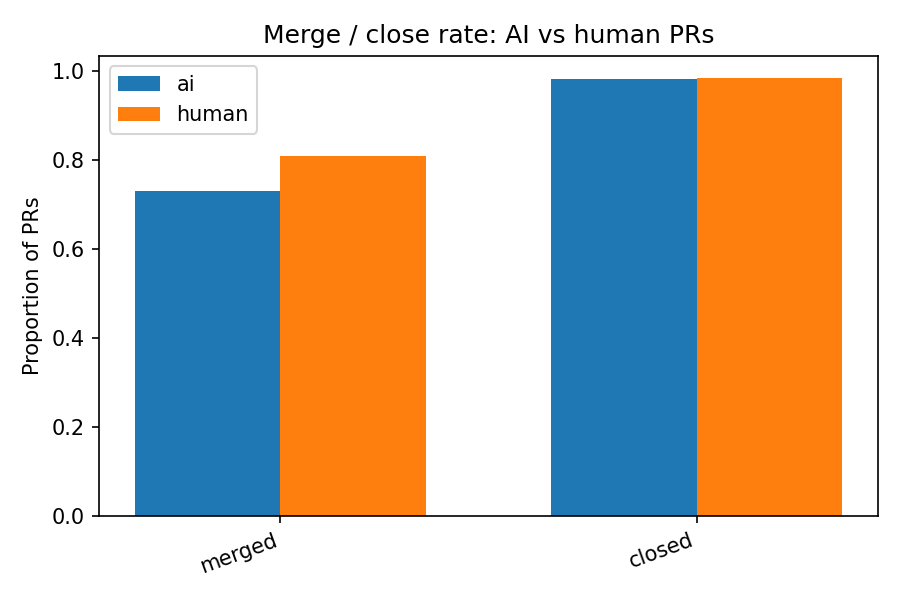

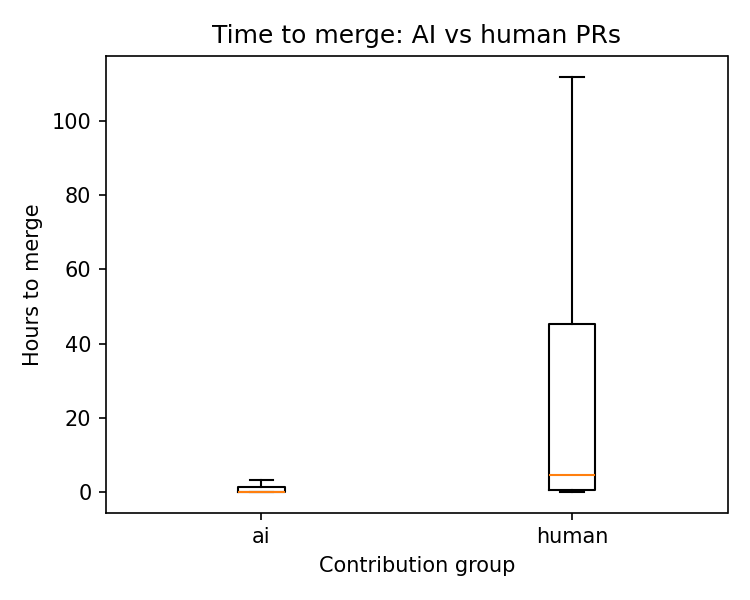

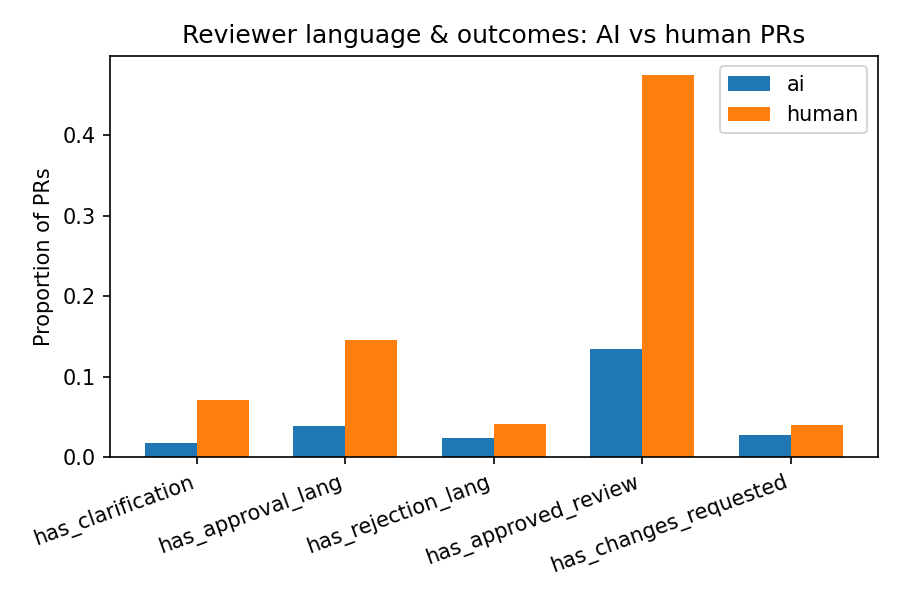

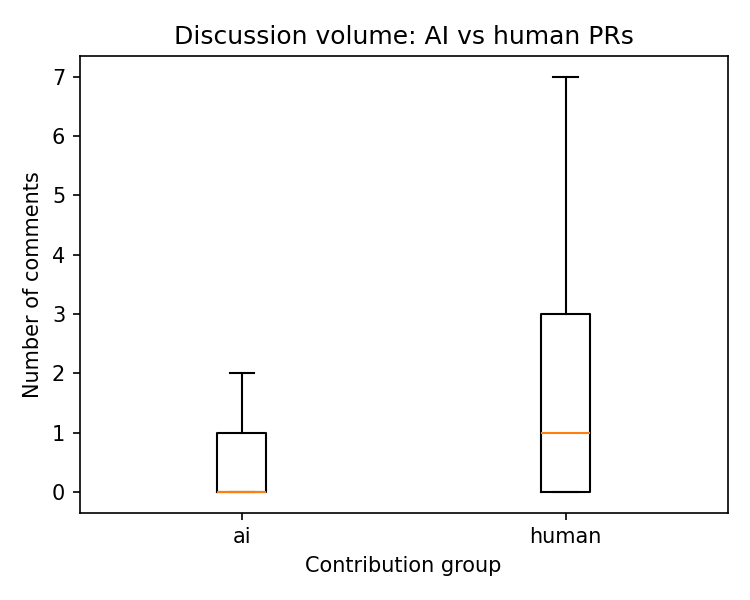

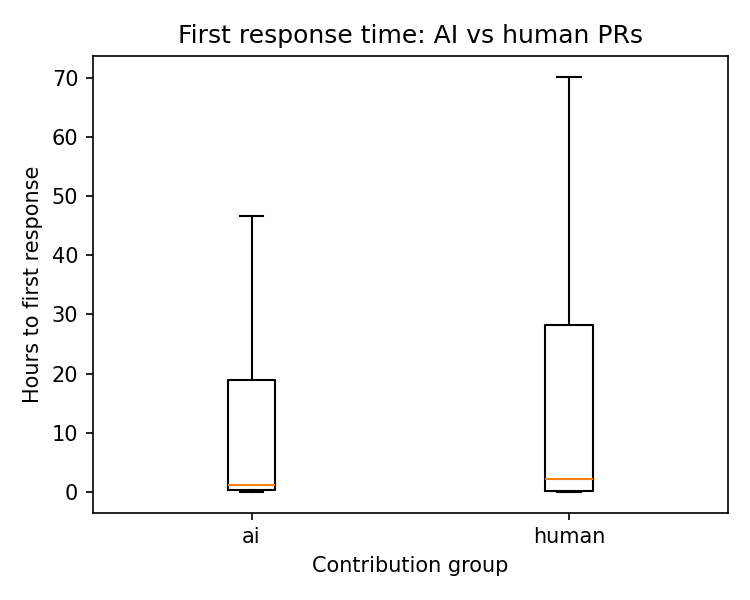

In [ ]:
from IPython.display import Image, display

for png in sorted(FIG_DIR.glob("*.png")):
    display(Image(filename=str(png)))

## Download your results

Zips `data/` (mined + cleaned data, metrics CSV, RQ result tables) and
`figures/` so you can pull them into your report/replication repo.

In [57]:
import os
print(os.listdir("/content/data"))

['data.jsonl', 'pull_request.parquet', '.cache', 'human_pull_request.parquet', 'metrics.csv']


In [58]:
import os

for root, dirs, files in os.walk("/content/data"):
    print(f"\n📁 {root}")
    for file in files:
        print(f"   📄 {file}")


📁 /content/data
   📄 data.jsonl
   📄 pull_request.parquet
   📄 human_pull_request.parquet
   📄 metrics.csv

📁 /content/data/.cache

📁 /content/data/.cache/huggingface
   📄 CACHEDIR.TAG
   📄 .gitignore

📁 /content/data/.cache/huggingface/trees
   📄 68ed5f4b80d27a9e057fc57567f38bd322ac73ec.json

📁 /content/data/.cache/huggingface/download
   📄 pull_request.parquet.lock
   📄 human_pull_request.parquet.lock
   📄 pull_request.parquet.metadata
   📄 human_pull_request.parquet.metadata


In [59]:
df = pd.read_csv(METRICS_PATH)

In [60]:
import pandas as pd

METRICS_PATH = "/content/data/metrics.csv"

df = pd.read_csv(METRICS_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (972, 29)

Columns:
['pr_id', 'group', 'agent', 'repo', 'number', 'found', 'n_comments', 'n_issue_comments', 'n_review_comments', 'n_reviews', 'n_reviewers', 'n_human_participants', 'comment_words_median', 'comment_words_mean', 'comment_words_total', 'n_texted_comments', 'first_response_at', 'response_time_h', 'n_alternations', 'has_clarification', 'n_clarifications', 'has_approval_lang', 'has_rejection_lang', 'has_approved_review', 'has_changes_requested', 'engaged', 'merged', 'closed', 'time_to_merge_h']

First 5 rows:


,pr_id,group,agent,repo,number,found,n_comments,n_issue_comments,n_review_comments,n_reviews,...,has_clarification,n_clarifications,has_approval_lang,has_rejection_lang,has_approved_review,has_changes_requested,engaged,merged,closed,time_to_merge_h
0,3152334527,ai,Devin,liam-hq/liam,2044,True,5,3,0,2,...,False,0,False,False,True,False,True,True,True,1.334444
1,3267221021,ai,OpenAI_Codex,KomodoPlatform/komodo-wallet,3005,True,1,1,0,0,...,False,0,False,False,False,False,True,True,True,4.232222
2,3245249710,ai,OpenAI_Codex,mochilang/mochi,10166,True,0,0,0,0,...,False,0,False,False,False,False,False,True,True,0.005000
3,3148163500,ai,OpenAI_Codex,MontrealAI/AGI-Alpha-Agent-v0,2221,True,0,0,0,0,...,False,0,False,False,False,False,False,True,True,0.003056
4,3083313712,ai,Copilot,AzureCosmosDB/data-migration-desktop-tool,187,True,15,11,0,4,...,False,0,False,False,True,False,True,True,True,6.006389


In [61]:
print("\nGroups:")
print(df.iloc[:, 0].value_counts())


Groups:
pr_id
2403152419    1
3152334527    1
3267221021    1
3245249710    1
3148163500    1
             ..
3200786626    1
3210172444    1
3089195459    1
3148949727    1
3124426557    1
Name: count, Length: 972, dtype: int64


In [62]:
print(df["group"].value_counts())

group
ai       488
human    484
Name: count, dtype: int64


In [63]:
import pandas as pd

df = pd.read_csv("/content/data/metrics.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (972, 29)

Columns:
['pr_id', 'group', 'agent', 'repo', 'number', 'found', 'n_comments', 'n_issue_comments', 'n_review_comments', 'n_reviews', 'n_reviewers', 'n_human_participants', 'comment_words_median', 'comment_words_mean', 'comment_words_total', 'n_texted_comments', 'first_response_at', 'response_time_h', 'n_alternations', 'has_clarification', 'n_clarifications', 'has_approval_lang', 'has_rejection_lang', 'has_approved_review', 'has_changes_requested', 'engaged', 'merged', 'closed', 'time_to_merge_h']

First 5 rows:


,pr_id,group,agent,repo,number,found,n_comments,n_issue_comments,n_review_comments,n_reviews,...,has_clarification,n_clarifications,has_approval_lang,has_rejection_lang,has_approved_review,has_changes_requested,engaged,merged,closed,time_to_merge_h
0,3152334527,ai,Devin,liam-hq/liam,2044,True,5,3,0,2,...,False,0,False,False,True,False,True,True,True,1.334444
1,3267221021,ai,OpenAI_Codex,KomodoPlatform/komodo-wallet,3005,True,1,1,0,0,...,False,0,False,False,False,False,True,True,True,4.232222
2,3245249710,ai,OpenAI_Codex,mochilang/mochi,10166,True,0,0,0,0,...,False,0,False,False,False,False,False,True,True,0.005000
3,3148163500,ai,OpenAI_Codex,MontrealAI/AGI-Alpha-Agent-v0,2221,True,0,0,0,0,...,False,0,False,False,False,False,False,True,True,0.003056
4,3083313712,ai,Copilot,AzureCosmosDB/data-migration-desktop-tool,187,True,15,11,0,4,...,False,0,False,False,True,False,True,True,True,6.006389


In [64]:
import os

FIGURES_DIR = "/content/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Figures folder ready:", FIGURES_DIR)

Figures folder ready: /content/figures


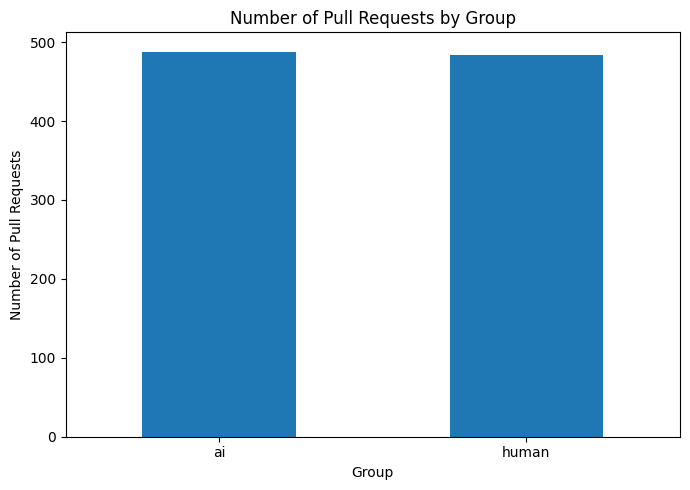

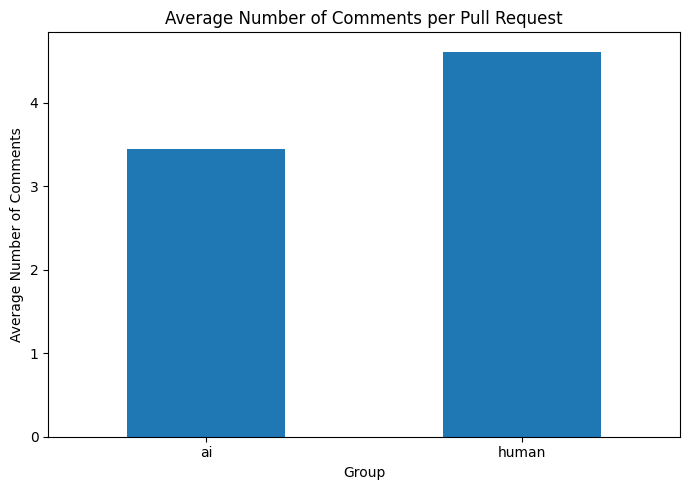

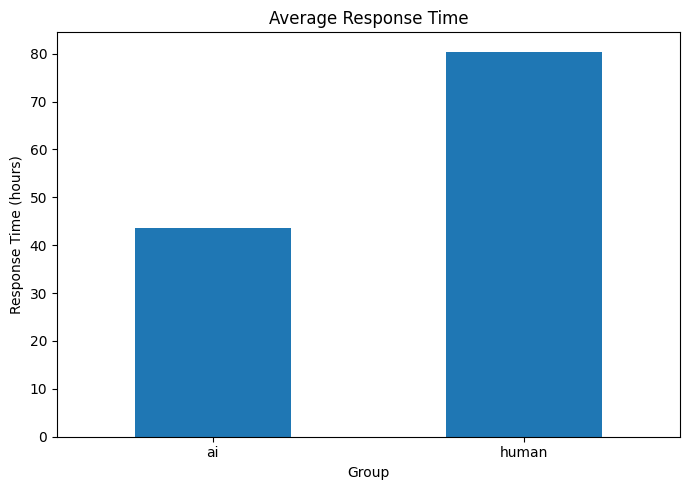

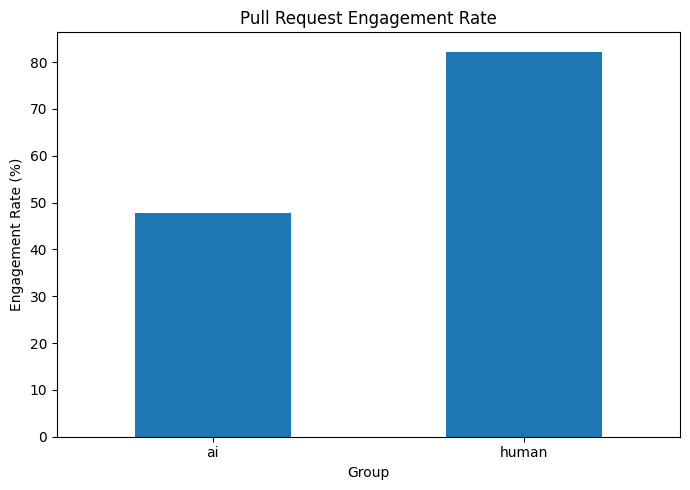

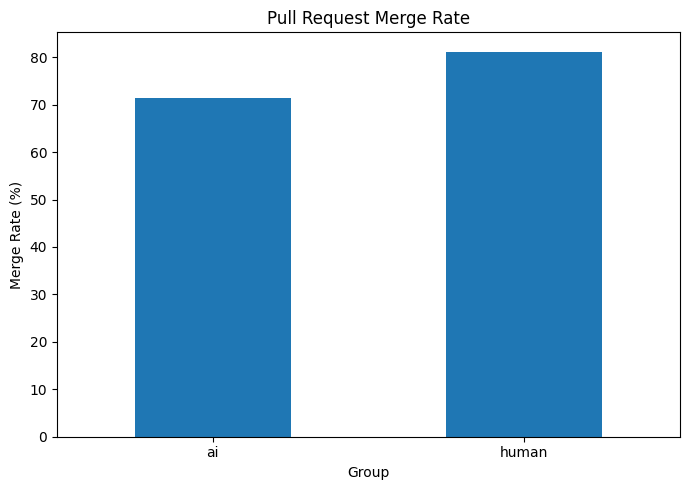

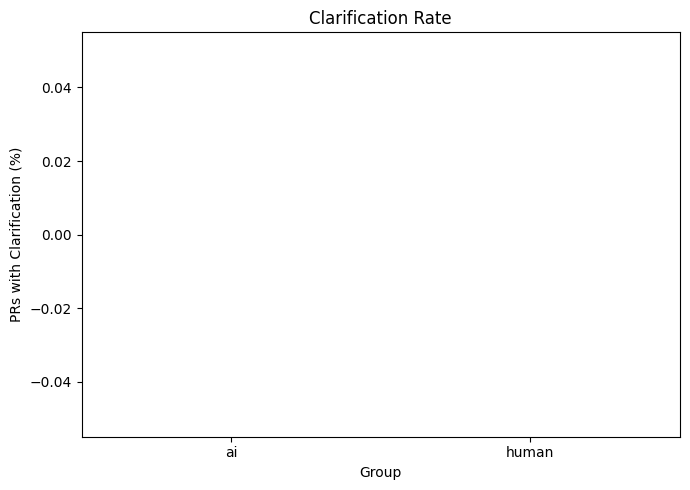

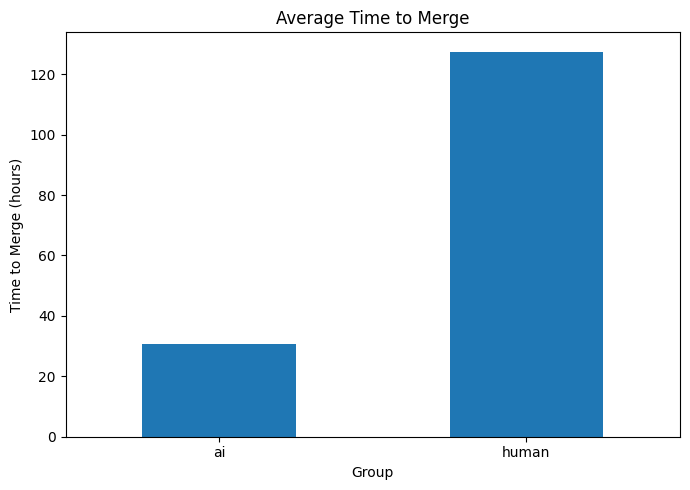

<Figure size 800x500 with 0 Axes>

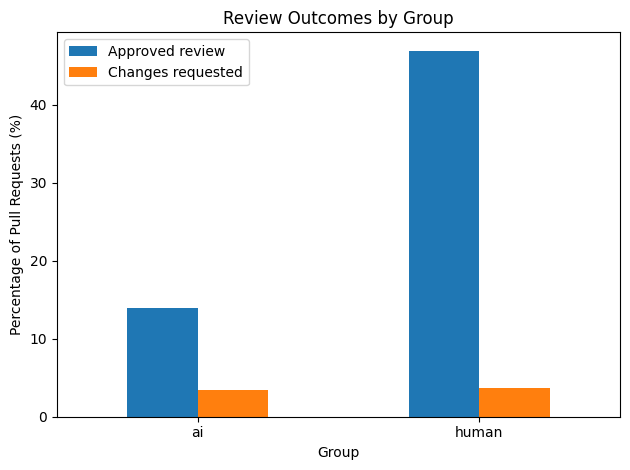


Generated figures:
✓ fig1_pr_count.png
✓ fig2_average_comments.png
✓ fig3_response_time.png
✓ fig4_engagement_rate.png
✓ fig5_merge_rate.png
✓ fig6_clarification_rate.png
✓ fig7_time_to_merge.png
✓ fig8_review_outcomes.png


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load data
df = pd.read_csv("/content/data/metrics.csv")

# Make sure boolean columns are numeric
bool_cols = [
    "engaged",
    "merged",
    "closed",
    "has_clarification",
    "has_approval_lang",
    "has_rejection_lang",
    "has_approved_review",
    "has_changes_requested"
]

for col in bool_cols:
    df[col] = df[col].astype(int)

FIGURES_DIR = "/content/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)


# ============================================================
# FIGURE 1 — Number of PRs: AI vs Human
# ============================================================

counts = df["group"].value_counts().reindex(["ai", "human"])

plt.figure(figsize=(7, 5))
counts.plot(kind="bar")
plt.title("Number of Pull Requests by Group")
plt.xlabel("Group")
plt.ylabel("Number of Pull Requests")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig1_pr_count.png", dpi=300)
plt.show()


# ============================================================
# FIGURE 2 — Average number of comments
# ============================================================

means = df.groupby("group")["n_comments"].mean().reindex(["ai", "human"])

plt.figure(figsize=(7, 5))
means.plot(kind="bar")
plt.title("Average Number of Comments per Pull Request")
plt.xlabel("Group")
plt.ylabel("Average Number of Comments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig2_average_comments.png", dpi=300)
plt.show()


# ============================================================
# FIGURE 3 — Average response time
# ============================================================

response = (
    df.groupby("group")["response_time_h"]
    .mean()
    .reindex(["ai", "human"])
)

plt.figure(figsize=(7, 5))
response.plot(kind="bar")
plt.title("Average Response Time")
plt.xlabel("Group")
plt.ylabel("Response Time (hours)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig3_response_time.png", dpi=300)
plt.show()


# ============================================================
# FIGURE 4 — Engagement rate
# ============================================================

engagement = (
    df.groupby("group")["engaged"]
    .mean()
    .reindex(["ai", "human"]) * 100
)

plt.figure(figsize=(7, 5))
engagement.plot(kind="bar")
plt.title("Pull Request Engagement Rate")
plt.xlabel("Group")
plt.ylabel("Engagement Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig4_engagement_rate.png", dpi=300)
plt.show()


# ============================================================
# FIGURE 5 — Merge rate
# ============================================================

merge_rate = (
    df.groupby("group")["merged"]
    .mean()
    .reindex(["ai", "human"]) * 100
)

plt.figure(figsize=(7, 5))
merge_rate.plot(kind="bar")
plt.title("Pull Request Merge Rate")
plt.xlabel("Group")
plt.ylabel("Merge Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig5_merge_rate.png", dpi=300)
plt.show()


# ============================================================
# FIGURE 6 — Clarification rate
# ============================================================

clarification = (
    df.groupby("group")["has_clarification"]
    .mean()
    .reindex(["ai", "human"]) * 100
)

plt.figure(figsize=(7, 5))
clarification.plot(kind="bar")
plt.title("Clarification Rate")
plt.xlabel("Group")
plt.ylabel("PRs with Clarification (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig6_clarification_rate.png", dpi=300)
plt.show()


# ============================================================
# FIGURE 7 — Average time to merge
# ============================================================

merge_time = (
    df.groupby("group")["time_to_merge_h"]
    .mean()
    .reindex(["ai", "human"])
)

plt.figure(figsize=(7, 5))
merge_time.plot(kind="bar")
plt.title("Average Time to Merge")
plt.xlabel("Group")
plt.ylabel("Time to Merge (hours)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig7_time_to_merge.png", dpi=300)
plt.show()


# ============================================================
# FIGURE 8 — Review outcomes
# ============================================================

review_outcomes = pd.DataFrame({
    "Approved review": df.groupby("group")["has_approved_review"].mean() * 100,
    "Changes requested": df.groupby("group")["has_changes_requested"].mean() * 100
}).reindex(["ai", "human"])

plt.figure(figsize=(8, 5))
review_outcomes.plot(kind="bar")
plt.title("Review Outcomes by Group")
plt.xlabel("Group")
plt.ylabel("Percentage of Pull Requests (%)")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig8_review_outcomes.png", dpi=300)
plt.show()


# ============================================================
# Check generated files
# ============================================================

print("\nGenerated figures:")
for file in sorted(os.listdir(FIGURES_DIR)):
    print("✓", file)

In [66]:
import os

print(os.listdir("/content/figures"))

['fig5_merge_rate.png', 'fig1_pr_count.png', 'fig4_engagement_rate.png', 'fig6_clarification_rate.png', 'fig8_review_outcomes.png', 'fig3_response_time.png', 'fig2_average_comments.png', 'fig7_time_to_merge.png']


In [67]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/mining_figures",
    "zip",
    "/content",
    "figures"
)

files.download("/content/mining_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
import pandas as pd
import numpy as np
from scipy import stats

# Load data
df = pd.read_csv("/content/data/metrics.csv")

ai = df[df["group"] == "ai"]
human = df[df["group"] == "human"]

print(f"AI PRs: {len(ai)}")
print(f"Human PRs: {len(human)}")


# ------------------------------------------------------------
# Functions
# ------------------------------------------------------------

def cohens_d(x, y):
    x = pd.Series(x).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)

    nx, ny = len(x), len(y)

    pooled_sd = np.sqrt(
        ((nx - 1) * x.var(ddof=1) +
         (ny - 1) * y.var(ddof=1))
        / (nx + ny - 2)
    )

    return (x.mean() - y.mean()) / pooled_sd


def bootstrap_mean_difference(x, y, n_boot=10000, seed=42):
    """
    Bootstrap 95% CI for AI mean - Human mean.
    """
    rng = np.random.default_rng(seed)

    x = pd.Series(x).dropna().astype(float).values
    y = pd.Series(y).dropna().astype(float).values

    observed = x.mean() - y.mean()

    boot_diffs = np.empty(n_boot)

    for i in range(n_boot):
        x_sample = rng.choice(x, size=len(x), replace=True)
        y_sample = rng.choice(y, size=len(y), replace=True)

        boot_diffs[i] = x_sample.mean() - y_sample.mean()

    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

    return observed, ci_low, ci_high


# ------------------------------------------------------------
# Continuous variables
# Mann-Whitney U is used because count/time data are often
# skewed in software-engineering datasets.
# ------------------------------------------------------------

continuous_metrics = [
    "n_comments",
    "n_issue_comments",
    "n_review_comments",
    "n_reviews",
    "n_reviewers",
    "n_human_participants",
    "comment_words_median",
    "comment_words_mean",
    "comment_words_total",
    "n_texted_comments",
    "response_time_h",
    "n_alternations",
    "n_clarifications",
    "time_to_merge_h"
]

results = []

for metric in continuous_metrics:

    x = ai[metric].dropna()
    y = human[metric].dropna()

    if len(x) == 0 or len(y) == 0:
        continue

    # Mann-Whitney U
    u_stat, p_value = stats.mannwhitneyu(
        x,
        y,
        alternative="two-sided"
    )

    # Effect size: rank-biserial correlation
    n1 = len(x)
    n2 = len(y)

    rank_biserial = (2 * u_stat) / (n1 * n2) - 1

    # Means and medians
    ai_mean = x.mean()
    human_mean = y.mean()

    ai_median = x.median()
    human_median = y.median()

    # Difference
    mean_diff = ai_mean - human_mean

    # Bootstrap CI
    _, ci_low, ci_high = bootstrap_mean_difference(x, y)

    results.append({
        "metric": metric,
        "AI_mean": ai_mean,
        "Human_mean": human_mean,
        "AI_median": ai_median,
        "Human_median": human_median,
        "Mean_difference_AI_minus_Human": mean_diff,
        "95CI_low": ci_low,
        "95CI_high": ci_high,
        "Mann_Whitney_U": u_stat,
        "p_value": p_value,
        "rank_biserial_effect": rank_biserial
    })


continuous_results = pd.DataFrame(results)


# ------------------------------------------------------------
# Multiple-testing correction
# Benjamini-Hochberg FDR
# ------------------------------------------------------------

from statsmodels.stats.multitest import multipletests

continuous_results["p_adjusted_FDR"] = multipletests(
    continuous_results["p_value"],
    method="fdr_bh"
)[1]

continuous_results["significant_FDR_0.05"] = (
    continuous_results["p_adjusted_FDR"] < 0.05
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

display(
    continuous_results.sort_values("p_adjusted_FDR")
)

AI PRs: 488
Human PRs: 484


,metric,AI_mean,Human_mean,AI_median,Human_median,Mean_difference_AI_minus_Human,95CI_low,95CI_high,Mann_Whitney_U,p_value,rank_biserial_effect,p_adjusted_FDR,significant_FDR_0.05
13,time_to_merge_h,30.7675,127.4833,0.0508,5.7372,-96.7158,-155.6555,-46.3733,31327.5000,0.0000,-0.5432,0.0000,True
5,n_human_participants,1.1270,2.0475,0.0000,2.0000,-0.9205,-1.1221,-0.7085,74092.5000,0.0000,-0.3726,0.0000,True
0,n_comments,3.4467,4.6116,0.0000,2.0000,-1.1648,-2.3616,0.0756,80416.5000,0.0000,-0.3191,0.0000,True
4,n_reviewers,0.5020,0.8926,0.0000,1.0000,-0.3905,-0.5079,-0.2691,84714.5000,0.0000,-0.2827,0.0000,True
3,n_reviews,1.1475,1.6488,0.0000,1.0000,-0.5012,-0.9990,0.0026,85953.0000,0.0000,-0.2722,0.0000,True
1,n_issue_comments,1.2951,1.7500,0.0000,1.0000,-0.4549,-0.8042,-0.0918,88575.0000,0.0000,-0.2500,0.0000,True
10,response_time_h,43.5940,80.4285,0.0025,0.0064,-36.8345,-115.9013,50.1184,34504.5000,0.3170,-0.0504,0.5548,False
2,n_review_comments,1.0041,1.2128,0.0000,0.0000,-0.2087,-0.7483,0.3326,114876.5000,0.2889,-0.0273,0.5548,False
11,n_alternations,1.3033,1.0744,0.0000,0.0000,0.2289,-0.2563,0.7398,115035.5000,0.3582,-0.0259,0.5572,False
6,comment_words_median,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,118096.0000,1.0000,0.0000,1.0000,False


In [71]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

df = pd.read_csv("/content/data/metrics.csv")

binary_metrics = [
    "has_clarification",
    "has_approval_lang",
    "has_rejection_lang",
    "has_approved_review",
    "has_changes_requested",
    "engaged",
    "merged",
    "closed"
]

binary_results = []

for metric in binary_metrics:

    # Convert to numeric 0/1
    values = pd.to_numeric(df[metric], errors="coerce")

    temp = pd.DataFrame({
        "group": df["group"],
        "value": values
    }).dropna()

    # Convert booleans if necessary
    temp["value"] = temp["value"].astype(int)

    # Create a guaranteed 2 x 2 table
    table = pd.crosstab(temp["group"], temp["value"])
    table = table.reindex(
        index=["ai", "human"],
        columns=[0, 1],
        fill_value=0
    )

    ai_0 = int(table.loc["ai", 0])
    ai_1 = int(table.loc["ai", 1])

    human_0 = int(table.loc["human", 0])
    human_1 = int(table.loc["human", 1])

    ai_total = ai_0 + ai_1
    human_total = human_0 + human_1

    ai_rate = ai_1 / ai_total if ai_total else np.nan
    human_rate = human_1 / human_total if human_total else np.nan

    difference_pp = (ai_rate - human_rate) * 100

    # Check whether both outcome categories actually exist
    if table.values.sum() == 0 or table[0].sum() == 0 or table[1].sum() == 0:

        # No variation in the outcome -> statistical comparison
        # is not meaningful.
        test = "Not applicable (no variation)"
        statistic = np.nan
        p_value = np.nan
        odds_ratio = np.nan

    else:

        # Fisher's exact test is robust for sparse 2x2 tables.
        odds_ratio, p_value = stats.fisher_exact(table)

        test = "Fisher's exact test"
        statistic = np.nan

    binary_results.append({
        "metric": metric,
        "AI_count": ai_1,
        "AI_total": ai_total,
        "AI_rate_%": ai_rate * 100,
        "Human_count": human_1,
        "Human_total": human_total,
        "Human_rate_%": human_rate * 100,
        "Difference_percentage_points": difference_pp,
        "test": test,
        "p_value": p_value,
        "odds_ratio_AI_vs_Human": odds_ratio
    })


binary_results = pd.DataFrame(binary_results)


# ------------------------------------------------------------
# Multiple-testing correction
# ------------------------------------------------------------

valid = binary_results["p_value"].notna()

binary_results["p_adjusted_FDR"] = np.nan

if valid.sum() > 0:
    binary_results.loc[valid, "p_adjusted_FDR"] = multipletests(
        binary_results.loc[valid, "p_value"],
        method="fdr_bh"
    )[1]

binary_results["significant_FDR_0.05"] = (
    binary_results["p_adjusted_FDR"] < 0.05
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

display(binary_results)

,metric,AI_count,AI_total,AI_rate_%,Human_count,Human_total,Human_rate_%,Difference_percentage_points,test,p_value,odds_ratio_AI_vs_Human,p_adjusted_FDR,significant_FDR_0.05
0,has_clarification,0,488,0.0000,0,484,0.0000,0.0000,Not applicable (no variation),NaN,NaN,NaN,False
1,has_approval_lang,0,488,0.0000,0,484,0.0000,0.0000,Not applicable (no variation),NaN,NaN,NaN,False
2,has_rejection_lang,0,488,0.0000,0,484,0.0000,0.0000,Not applicable (no variation),NaN,NaN,NaN,False
3,has_approved_review,68,488,13.9344,227,484,46.9008,-32.9664,Fisher's exact test,0.0000,5.4555,0.0000,True
4,has_changes_requested,17,488,3.4836,18,484,3.7190,-0.2354,Fisher's exact test,0.8650,1.0702,1.0000,False
5,engaged,233,488,47.7459,398,484,82.2314,-34.4855,Fisher's exact test,0.0000,5.0649,0.0000,True
6,merged,349,488,71.5164,393,484,81.1983,-9.6820,Fisher's exact test,0.0004,1.7200,0.0006,True
7,closed,480,488,98.3607,477,484,98.5537,-0.1931,Fisher's exact test,1.0000,1.1357,1.0000,False


In [72]:
binary_results.to_csv(
    "/content/data/binary_statistical_results.csv",
    index=False
)

print("✅ Binary statistical analysis saved.")

✅ Binary statistical analysis saved.


In [73]:
for metric in binary_metrics:
    print(f"\n{metric}")
    print(pd.crosstab(df["group"], df[metric]))


has_clarification
has_clarification  False
group                   
ai                   488
human                484

has_approval_lang
has_approval_lang  False
group                   
ai                   488
human                484

has_rejection_lang
has_rejection_lang  False
group                    
ai                    488
human                 484

has_approved_review
has_approved_review  False  True 
group                            
ai                     420     68
human                  257    227

has_changes_requested
has_changes_requested  False  True 
group                              
ai                       471     17
human                    466     18

engaged
engaged  False  True 
group                
ai         255    233
human       86    398

merged
merged  False  True 
group               
ai        139    349
human      91    393

closed
closed  False  True 
group               
ai          8    480
human       7    477


In [74]:
binary_report = binary_results.copy()

def format_p(p):
    if pd.isna(p):
        return "N/A"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

binary_report["p_value_report"] = binary_report["p_value"].apply(format_p)
binary_report["FDR_p_report"] = binary_report["p_adjusted_FDR"].apply(format_p)

binary_report["AI_rate_report"] = (
    binary_report["AI_rate_%"].map(lambda x: f"{x:.2f}%")
)

binary_report["Human_rate_report"] = (
    binary_report["Human_rate_%"].map(lambda x: f"{x:.2f}%")
)

binary_report["Difference_report"] = (
    binary_report["Difference_percentage_points"]
    .map(lambda x: f"{x:+.2f} pp")
)

display(
    binary_report[
        [
            "metric",
            "AI_count",
            "AI_rate_report",
            "Human_count",
            "Human_rate_report",
            "Difference_report",
            "test",
            "p_value_report",
            "FDR_p_report",
            "odds_ratio_AI_vs_Human",
            "significant_FDR_0.05"
        ]
    ]
)

,metric,AI_count,AI_rate_report,Human_count,Human_rate_report,Difference_report,test,p_value_report,FDR_p_report,odds_ratio_AI_vs_Human,significant_FDR_0.05
0,has_clarification,0,0.00%,0,0.00%,+0.00 pp,Not applicable (no variation),N/A,N/A,NaN,False
1,has_approval_lang,0,0.00%,0,0.00%,+0.00 pp,Not applicable (no variation),N/A,N/A,NaN,False
2,has_rejection_lang,0,0.00%,0,0.00%,+0.00 pp,Not applicable (no variation),N/A,N/A,NaN,False
3,has_approved_review,68,13.93%,227,46.90%,-32.97 pp,Fisher's exact test,<0.001,<0.001,5.4555,True
4,has_changes_requested,17,3.48%,18,3.72%,-0.24 pp,Fisher's exact test,0.865,1.000,1.0702,False
5,engaged,233,47.75%,398,82.23%,-34.49 pp,Fisher's exact test,<0.001,<0.001,5.0649,True
6,merged,349,71.52%,393,81.20%,-9.68 pp,Fisher's exact test,<0.001,<0.001,1.7200,True
7,closed,480,98.36%,477,98.55%,-0.19 pp,Fisher's exact test,1.000,1.000,1.1357,False


In [75]:
binary_report.to_csv(
    "/content/data/binary_results_report_ready.csv",
    index=False
)

print("✅ Report-ready binary results saved.")

✅ Report-ready binary results saved.


In [76]:
binary_results["odds_ratio_AI_vs_Human_correct"] = (
    1 / binary_results["odds_ratio_AI_vs_Human"]
)

binary_results[
    ["metric", "odds_ratio_AI_vs_Human", "odds_ratio_AI_vs_Human_correct"]
]

,metric,odds_ratio_AI_vs_Human,odds_ratio_AI_vs_Human_correct
0,has_clarification,NaN,NaN
1,has_approval_lang,NaN,NaN
2,has_rejection_lang,NaN,NaN
3,has_approved_review,5.4555,0.1833
4,has_changes_requested,1.0702,0.9344
5,engaged,5.0649,0.1974
6,merged,1.7200,0.5814
7,closed,1.1357,0.8805


In [77]:
binary_results = binary_results.drop(
    columns=["odds_ratio_AI_vs_Human"]
).rename(
    columns={"odds_ratio_AI_vs_Human_correct": "odds_ratio_AI_vs_Human"}
)

In [78]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ============================================================
# 1. Load metrics
# ============================================================

METRICS_PATH = "/content/data/metrics.csv"
df = pd.read_csv(METRICS_PATH)

print("Dataset shape:", df.shape)
print("Groups:")
print(df["group"].value_counts())


# ============================================================
# 2. Continuous metrics
# ============================================================

continuous_metrics = [
    "n_comments",
    "n_issue_comments",
    "n_review_comments",
    "n_reviews",
    "n_reviewers",
    "n_human_participants",
    "comment_words_median",
    "comment_words_mean",
    "comment_words_total",
    "n_texted_comments",
    "response_time_h",
    "n_alternations",
    "n_clarifications",
    "time_to_merge_h"
]


# ============================================================
# 3. Rank-biserial effect size
# ============================================================

def rank_biserial_from_u(U, n_ai, n_human):
    """
    Rank-biserial correlation.

    Positive value:
        AI tends to have larger values.

    Negative value:
        Human tends to have larger values.
    """

    return (2 * U) / (n_ai * n_human) - 1


# ============================================================
# 4. Analyze each metric
# ============================================================

results = []

for metric in continuous_metrics:

    ai = pd.to_numeric(
        df.loc[df["group"].str.lower() == "ai", metric],
        errors="coerce"
    ).dropna()

    human = pd.to_numeric(
        df.loc[df["group"].str.lower() == "human", metric],
        errors="coerce"
    ).dropna()

    n_ai = len(ai)
    n_human = len(human)

    # Skip if one group has no observations
    if n_ai == 0 or n_human == 0:
        continue

    # Mann-Whitney U
    U, p = mannwhitneyu(
        ai,
        human,
        alternative="two-sided"
    )

    # Effect size
    effect = rank_biserial_from_u(
        U,
        n_ai,
        n_human
    )

    # Mean difference
    mean_diff = ai.mean() - human.mean()

    # Median difference
    median_diff = ai.median() - human.median()

    # IQR
    ai_q1 = ai.quantile(0.25)
    ai_q3 = ai.quantile(0.75)

    human_q1 = human.quantile(0.25)
    human_q3 = human.quantile(0.75)

    results.append({
        "metric": metric,

        "AI_n": n_ai,
        "Human_n": n_human,

        "AI_mean": ai.mean(),
        "Human_mean": human.mean(),

        "AI_median": ai.median(),
        "Human_median": human.median(),

        "AI_IQR": ai_q3 - ai_q1,
        "Human_IQR": human_q3 - human_q1,

        "mean_difference_AI_minus_Human": mean_diff,
        "median_difference_AI_minus_Human": median_diff,

        "U_statistic": U,
        "p_value": p,

        "rank_biserial": effect
    })


continuous_results = pd.DataFrame(results)


# ============================================================
# 5. FDR correction
# ============================================================

if len(continuous_results) > 0:

    rejected, p_adjusted, _, _ = multipletests(
        continuous_results["p_value"],
        alpha=0.05,
        method="fdr_bh"
    )

    continuous_results["FDR_p"] = p_adjusted
    continuous_results["significant_FDR_0.05"] = rejected


# ============================================================
# 6. Sort by statistical significance
# ============================================================

continuous_results = continuous_results.sort_values(
    "FDR_p"
).reset_index(drop=True)


# ============================================================
# 7. Display results
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("\n===== CONTINUOUS VARIABLE RESULTS =====\n")

print(
    continuous_results[
        [
            "metric",
            "AI_n",
            "Human_n",
            "AI_mean",
            "Human_mean",
            "AI_median",
            "Human_median",
            "mean_difference_AI_minus_Human",
            "median_difference_AI_minus_Human",
            "p_value",
            "FDR_p",
            "rank_biserial",
            "significant_FDR_0.05"
        ]
    ].to_string(index=False)
)


# ============================================================
# 8. Save results
# ============================================================

OUTPUT_PATH = "/content/data/continuous_results.csv"

continuous_results.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\nSaved to:")
print(OUTPUT_PATH)

Dataset shape: (972, 29)
Groups:
group
ai       488
human    484
Name: count, dtype: int64

===== CONTINUOUS VARIABLE RESULTS =====

              metric  AI_n  Human_n  AI_mean  Human_mean  AI_median  Human_median  mean_difference_AI_minus_Human  median_difference_AI_minus_Human  p_value  FDR_p  rank_biserial  significant_FDR_0.05
     time_to_merge_h   349      393  30.7675    127.4833     0.0508        5.7372                        -96.7158                           -5.6864   0.0000 0.0000        -0.5432                  True
n_human_participants   488      484   1.1270      2.0475     0.0000        2.0000                         -0.9205                           -2.0000   0.0000 0.0000        -0.3726                  True
          n_comments   488      484   3.4467      4.6116     0.0000        2.0000                         -1.1648                           -2.0000   0.0000 0.0000        -0.3191                  True
         n_reviewers   488      484   0.5020      0.8926     0.

In [79]:
report = continuous_results.copy()

report["p_value_report"] = report["p_value"].apply(
    lambda x: "<0.001" if x < 0.001 else f"{x:.4f}"
)

report["FDR_p_report"] = report["FDR_p"].apply(
    lambda x: "<0.001" if x < 0.001 else f"{x:.4f}"
)

report["mean_difference_report"] = report[
    "mean_difference_AI_minus_Human"
].apply(lambda x: f"{x:.2f}")

report["median_difference_report"] = report[
    "median_difference_AI_minus_Human"
].apply(lambda x: f"{x:.2f}")

report["rank_biserial_report"] = report[
    "rank_biserial"
].apply(lambda x: f"{x:.3f}")

report[
    [
        "metric",
        "AI_n",
        "Human_n",
        "AI_mean",
        "Human_mean",
        "AI_median",
        "Human_median",
        "mean_difference_report",
        "median_difference_report",
        "p_value_report",
        "FDR_p_report",
        "rank_biserial_report",
        "significant_FDR_0.05"
    ]
]

,metric,AI_n,Human_n,AI_mean,Human_mean,AI_median,Human_median,mean_difference_report,median_difference_report,p_value_report,FDR_p_report,rank_biserial_report,significant_FDR_0.05
0,time_to_merge_h,349,393,30.7675,127.4833,0.0508,5.7372,-96.72,-5.69,<0.001,<0.001,-0.543,True
1,n_human_participants,488,484,1.1270,2.0475,0.0000,2.0000,-0.92,-2.00,<0.001,<0.001,-0.373,True
2,n_comments,488,484,3.4467,4.6116,0.0000,2.0000,-1.16,-2.00,<0.001,<0.001,-0.319,True
3,n_reviewers,488,484,0.5020,0.8926,0.0000,1.0000,-0.39,-1.00,<0.001,<0.001,-0.283,True
4,n_reviews,488,484,1.1475,1.6488,0.0000,1.0000,-0.50,-1.00,<0.001,<0.001,-0.272,True
5,n_issue_comments,488,484,1.2951,1.7500,0.0000,1.0000,-0.45,-1.00,<0.001,<0.001,-0.250,True
6,response_time_h,215,338,43.5940,80.4285,0.0025,0.0064,-36.83,-0.00,0.3170,0.5548,-0.050,False
7,n_review_comments,488,484,1.0041,1.2128,0.0000,0.0000,-0.21,0.00,0.2889,0.5548,-0.027,False
8,n_alternations,488,484,1.3033,1.0744,0.0000,0.0000,0.23,0.00,0.3582,0.5572,-0.026,False
9,comment_words_median,488,484,0.0000,0.0000,0.0000,0.0000,0.00,0.00,1.0000,1.0000,0.000,False
